In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
DATASET_DIR = "Utils/Dataset/AFDB/CSV_Files/hrv_features.csv"

In [3]:
df = pd.read_csv(DATASET_DIR)

In [26]:
df.head(10000)


,Segment_Name,start_idx,end_idx,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_RMSSD,HRV_SDSD,HRV_CVNN,...,L,Divergence,LEn,Laminarity,TrappingTime,VMax,VEn,W,WMax,WEn
0,04043_ep02,0,50,557.04,6.505759,NaN,NaN,9.646825,9.743653,0.011679,...,2.444444,0.250000,0.848686,0.051282,2.000000,2,0.000000,13.256098,40,3.214762
1,04043_ep02,10,60,557.44,6.749633,NaN,NaN,10.141851,10.246619,0.012108,...,3.142857,0.200000,1.277034,0.048780,2.000000,2,0.000000,12.916667,47,3.118921
2,04043_ep02,20,70,557.76,6.720544,NaN,NaN,9.963198,10.065094,0.012049,...,3.090909,0.142857,1.120950,0.000000,0.000000,0,0.000000,11.602151,38,2.897235
3,04043_ep02,30,80,558.40,6.857143,NaN,NaN,9.995918,10.094115,0.012280,...,2.571429,0.250000,0.598270,0.054054,2.000000,2,0.000000,13.612500,45,2.932928
4,04043_ep02,40,90,558.88,6.859047,NaN,NaN,9.831229,9.931740,0.012273,...,2.714286,0.250000,0.955700,0.000000,0.000000,0,0.000000,15.450704,41,3.179089
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,06995_ep04,4760,4810,614.56,106.876270,NaN,NaN,128.659018,129.675314,0.173907,...,2.666667,0.250000,0.918428,0.375000,2.571429,3,0.682908,14.767123,41,3.118755
9996,06995_ep04,4770,4820,651.84,117.280644,NaN,NaN,125.763627,127.048815,0.179922,...,2.571429,0.250000,0.898205,0.396552,2.300000,4,0.639032,13.518987,41,2.970667
9997,06995_ep04,4780,4830,663.20,126.261148,NaN,NaN,140.874238,142.070405,0.190382,...,3.812500,0.090909,1.440235,0.670732,2.894737,4,1.079530,13.545455,43,2.964902
9998,06995_ep04,4790,4840,674.48,113.119449,NaN,NaN,131.227175,132.586976,0.167714,...,4.150000,0.090909,1.817382,0.612245,5.000000,8,1.907284,13.500000,47,2.718832


In [38]:
segment_01 = df[df['Segment_Name'] == '04126_ep05']

In [39]:
hrv_features = ['HRV_RMSSD', 'HRV_DFA_alpha1', 'HRV_ApEn','HRV_pNN50']
df_ = segment_01[hrv_features]

In [40]:
hrv_rmssd_outlier_removed = df_['HRV_RMSSD'].clip(lower=df_['HRV_RMSSD'].quantile(0.05), upper=df_['HRV_RMSSD'].quantile(0.95))
hrv_pnn50_outlier_removed = df_['HRV_pNN50'].clip(lower=df_['HRV_pNN50'].quantile(0.05), upper=df_['HRV_pNN50'].quantile(0.95))

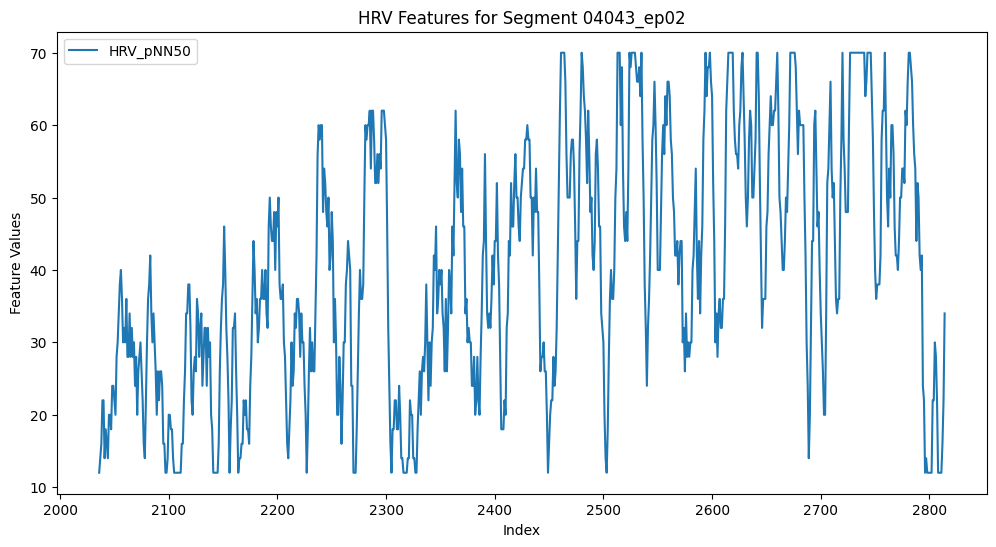

In [41]:
plt.figure(figsize=(12, 6))
# plt.plot(df_.index, hrv_rmssd_outlier_removed, label='HRV_RMSSD')
plt.plot(df_.index, hrv_pnn50_outlier_removed, label='HRV_pNN50')
plt.xlabel('Index')
plt.ylabel('Feature Values')    
plt.title('HRV Features for Segment 04043_ep02')
plt.legend()
plt.show()

In [121]:
df_02 = pd.read_csv('hrv_features.csv')

In [122]:
segment_01_ = df_02[df_02['Segment_Name'] == '04126_ep05']

In [123]:
df_02_ = segment_01_[hrv_features]
hrv_rmssd_outlier_removed_02 = df_02_['HRV_RMSSD'].clip(lower=df_02_['HRV_RMSSD'].quantile(0.05), upper=df_02_['HRV_RMSSD'].quantile(0.95))
total_length_of_features = len(hrv_rmssd_outlier_removed_02)
print(f"Total length of features: {total_length_of_features}")


Total length of features: 754


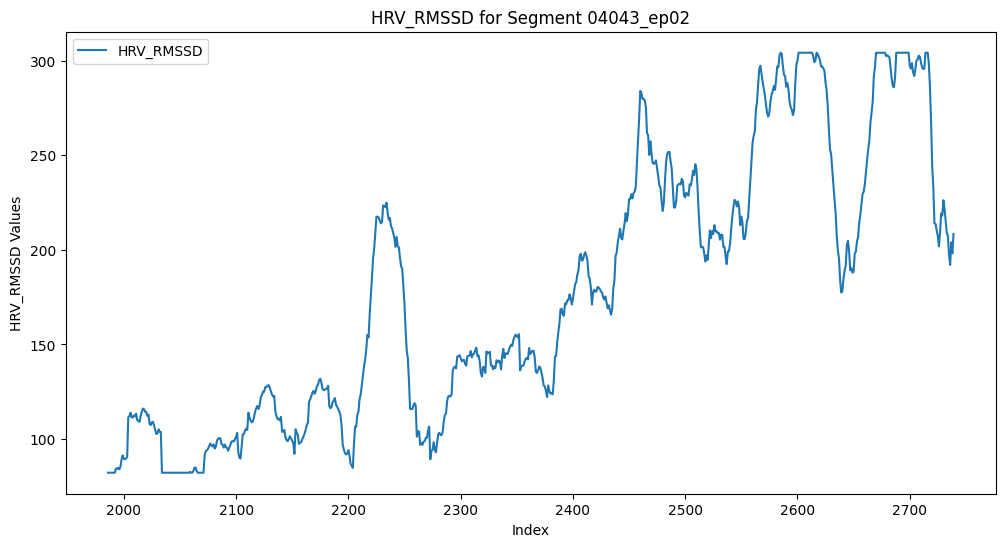

In [124]:
plt.figure(figsize=(12, 6))
plt.plot(hrv_rmssd_outlier_removed_02.index, hrv_rmssd_outlier_removed_02, label='HRV_RMSSD')
plt.xlabel('Index')
plt.ylabel('HRV_RMSSD Values')
plt.title('HRV_RMSSD for Segment 04043_ep02')
plt.legend()
plt.show()

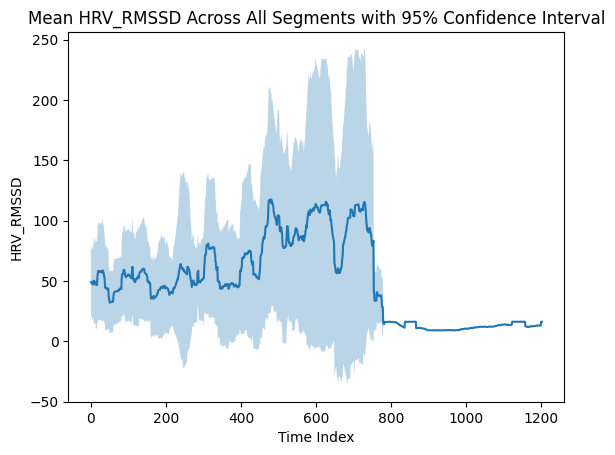

In [51]:
# Ensure we are using default font (DejaVu Sans) for Latin text
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter only required features
df_all = df_02[['Segment_Name', 'HRV_RMSSD']].copy()

# Create a time index within each segment
df_all['time_idx'] = df_all.groupby('Segment_Name').cumcount()

# Pivot so each column is a segment, indexed by time
pivot_df = df_all.pivot(index='time_idx', columns='Segment_Name', values='HRV_RMSSD')

# Remove outliers per segment using 5th–95th percentile clipping
pivot_clipped = pivot_df.copy()
for col in pivot_clipped.columns:
    lower = pivot_clipped[col].quantile(0.05)
    upper = pivot_clipped[col].quantile(0.95)
    pivot_clipped[col] = pivot_clipped[col].clip(lower=lower, upper=upper)

# Compute mean and 95% confidence interval
mean_series = pivot_clipped.mean(axis=1)
std_series = pivot_clipped.std(axis=1)
n_segments = pivot_clipped.count(axis=1)

ci_95 = 1.96 * (std_series / np.sqrt(n_segments))

# Plot mean with 95% confidence interval shaded
plt.figure()
plt.plot(mean_series.index, mean_series)
plt.fill_between(mean_series.index,
                 mean_series - ci_95,
                 mean_series + ci_95,
                 alpha=0.3)

plt.xlabel("Time Index")
plt.ylabel("HRV_RMSSD")
plt.title("Mean HRV_RMSSD Across All Segments with 95% Confidence Interval")
plt.show()

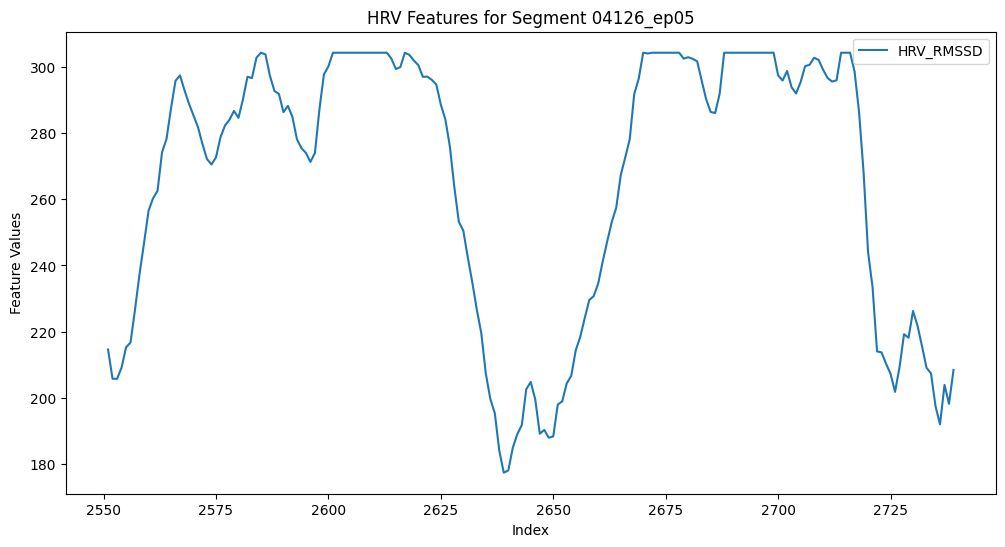

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(hrv_rmssd_before_30_min, label='HRV_RMSSD')
# plt.plot(df_02_.index, hrv_pnn50_outlier_removed_02, label='HRV_pNN50')
plt.xlabel('Index')
plt.ylabel('Feature Values')
plt.title('HRV Features for Segment 04126_ep05')
plt.legend()
plt.show()

In [53]:
import wfdb
DATASET_PATH = '/Users/yasantha-mac/Downloads/paf-prediction-challenge-database-1.0.0'

In [620]:
record = wfdb.rdrecord(f"{DATASET_PATH}/p38")

In [621]:
qrs = wfdb.rdann(f"{DATASET_PATH}/p38", 'qrs')

In [622]:
qrs_data = qrs.sample
print(qrs_data)

[    14    107    200 ... 230168 230261 230355]


In [623]:
rr_data = np.diff(qrs_data)/record.fs*1000
print(rr_data)

[726.5625 726.5625 750.     ... 750.     726.5625 734.375 ]


In [624]:
def RMSSD(rr_intervals):
    return np.sqrt(np.mean(np.diff(rr_intervals)**2))

In [625]:
window_size = 300 # 50 RR intervals, which is approximately 1 minute of data at a heart rate of 60 bpm
stride = 10 # Move the window by 10 RR intervals for the next calculation

In [626]:
windows = []
for start in range(0, len(rr_data) - window_size + 1, stride):
    end = start + window_size
    window_rr = rr_data[start:end]
    rmssd_value = RMSSD(window_rr)
    windows.append(rmssd_value)

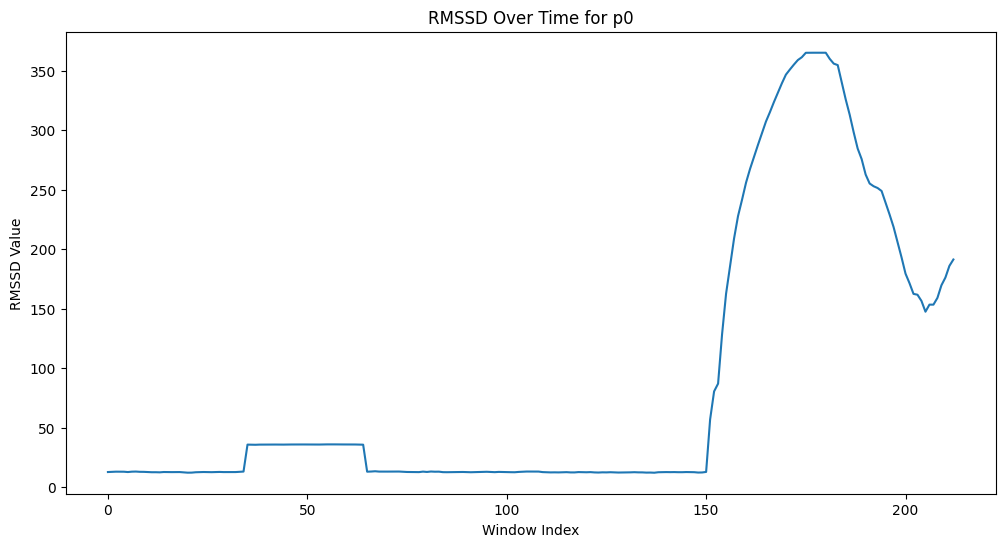

In [627]:
plt.figure(figsize=(12, 6))
plt.plot(windows)
plt.xlabel('Window Index')
plt.ylabel('RMSSD Value')
plt.title('RMSSD Over Time for p0')
plt.show()

In [628]:
# less than 600 or more than 1200 milliseconds
anomalies = (rr_data < 500) | (rr_data > 1200)
anomalies_indices = np.where(anomalies)[0]
print("Anomalous RR intervals (ms):", rr_data[anomalies])
print("Indices of anomalous RR intervals:", anomalies_indices)
print(f"Length of anomalous RR intervals: {len(anomalies_indices)}")


Anomalous RR intervals (ms): [492.1875 257.8125 492.1875 460.9375 445.3125 468.75   445.3125 492.1875
 468.75   312.5    484.375  492.1875 492.1875 492.1875 476.5625 484.375
 476.5625 484.375  484.375  484.375  484.375  484.375  476.5625 484.375
 484.375  484.375  476.5625 492.1875 492.1875 492.1875 492.1875 484.375
 468.75   484.375  492.1875 476.5625 484.375  476.5625 484.375  476.5625
 484.375  492.1875 484.375  492.1875 492.1875 476.5625]
Indices of anomalous RR intervals: [ 642  643 1806 1816 1817 1824 1825 1828 1830 1831 1833 1835 1841 1843
 1847 1859 1863 1867 1873 1877 1891 1895 1915 1933 1943 1947 1961 1979
 2036 2043 2046 2180 2200 2211 2233 2321 2323 2350 2375 2378 2386 2390
 2392 2402 2411 2414]
Length of anomalous RR intervals: 46


In [629]:
threshold = 0.2 * np.mean(rr_data)  # Example threshold at 20% of the mean RR interval
diff_mask = np.abs(np.diff(rr_data)) > threshold * rr_data[:-1]

cleaned_rr_data = rr_data[1:][~diff_mask]
print("Cleaned RR intervals (ms):", cleaned_rr_data)

Cleaned RR intervals (ms): [726.5625 750.     750.     ... 750.     726.5625 734.375 ]


In [630]:
rpeaks = qrs.sample[100:220]
ecg_data = record.p_signal[:, 0][rpeaks[0]:rpeaks[-1]]
print(np.diff(rpeaks)/record.fs*1000)

[765.625  773.4375 757.8125 750.     765.625  750.     757.8125 750.
 773.4375 757.8125 750.     742.1875 750.     750.     734.375  742.1875
 765.625  742.1875 742.1875 742.1875 742.1875 734.375  765.625  750.
 742.1875 757.8125 765.625  750.     750.     765.625  750.     757.8125
 750.     750.     742.1875 742.1875 757.8125 757.8125 742.1875 734.375
 757.8125 750.     734.375  742.1875 757.8125 742.1875 742.1875 750.
 742.1875 734.375  757.8125 750.     734.375  734.375  750.     742.1875
 734.375  750.     734.375  734.375  742.1875 757.8125 734.375  750.
 750.     734.375  750.     750.     750.     734.375  742.1875 734.375
 742.1875 734.375  750.     734.375  750.     742.1875 757.8125 742.1875
 734.375  750.     742.1875 734.375  734.375  757.8125 734.375  734.375
 765.625  750.     734.375  765.625  742.1875 742.1875 757.8125 757.8125
 734.375  734.375  757.8125 734.375  742.1875 742.1875 750.     734.375
 757.8125 750.     750.     742.1875 742.1875 734.375  742.1875 734.375

In [631]:
import numpy as np
import pandas as pd

def local_variability_filter(
    rr_intervals,
    threshold=0.25,      # 25% variability threshold
    window_size=5,       # local median window (must be odd)
    remove_following=True
):
    """
    Local Variability Threshold (LVT) filtering for RR intervals.
    
    Parameters:
    -----------
    rr_intervals : array-like
        RR intervals in milliseconds or seconds
    threshold : float
        Fractional deviation allowed from local median (e.g., 0.25 = 25%)
    window_size : int
        Window size for local median filtering (odd number recommended)
    remove_following : bool
        If True, remove the interval immediately after a detected outlier
    
    Returns:
    --------
    rr_corrected : np.ndarray
        Cleaned RR interval sequence
    n_edited : int
        Number of RR intervals that were replaced
    edited_indices : np.ndarray
        Indices of edited intervals
    """

    rr = np.array(rr_intervals, dtype=float)
    rr_series = pd.Series(rr)

    # Compute rolling median (centered window)
    local_median = rr_series.rolling(
        window=window_size, 
        center=True, 
        min_periods=1
    ).median().values

    # Detect outliers
    deviation = np.abs(rr - local_median)
    outliers = deviation > (threshold * local_median)

    # Mark indices to remove
    to_edit = outliers.copy()

    if remove_following:
        following_indices = np.where(outliers)[0] + 1
        following_indices = following_indices[following_indices < len(rr)]
        to_edit[following_indices] = True

    edited_indices = np.where(to_edit)[0]

    # Replace detected intervals with NaN for interpolation
    rr_corrected = rr.copy()
    rr_corrected[to_edit] = np.nan

    # Linear interpolation
    rr_corrected = pd.Series(rr_corrected).interpolate(
        method='linear', 
        limit_direction='both'
    ).values

    n_edited = len(edited_indices)

    return rr_corrected, n_edited, edited_indices

In [632]:
print(rr_data)

[726.5625 726.5625 750.     ... 750.     726.5625 734.375 ]


In [633]:
rr_cleaned, edited_count, edited_idx = local_variability_filter(
    rr_data,
    threshold=0.25,
    window_size=5,
    remove_following=False
)

print("Number of RR intervals edited:", edited_count)
print("Percentage of RR intervals edited: {:.2f}%".format(edited_count / len(rr_data) * 100))

Number of RR intervals edited: 44
Percentage of RR intervals edited: 1.82%


In [634]:
anomalies_indices = np.where((rr_cleaned < 500) | (rr_cleaned > 1200))[0]
anomalies_values = rr_cleaned[anomalies_indices]
print("Anomalous RR intervals after cleaning (ms):", anomalies_values)
print("Indices of anomalous RR intervals after cleaning:", anomalies_indices)
print(f"Length of anomalous RR intervals after cleaning: {len(anomalies_indices)}")

Anomalous RR intervals after cleaning (ms): [492.1875     460.9375     445.3125     476.5625     468.75
 445.3125     492.1875     468.75       473.95833333 479.16666667
 484.375      492.1875     492.1875     492.1875     476.5625
 484.375      476.5625     484.375      484.375      484.375
 484.375      484.375      476.5625     484.375      484.375
 484.375      476.5625     492.1875     492.1875     492.1875    ]
Indices of anomalous RR intervals after cleaning: [1806 1816 1817 1818 1824 1825 1828 1830 1831 1832 1833 1835 1841 1843
 1847 1859 1863 1867 1873 1877 1891 1895 1915 1933 1943 1947 1961 1979
 2233 2390]
Length of anomalous RR intervals after cleaning: 30


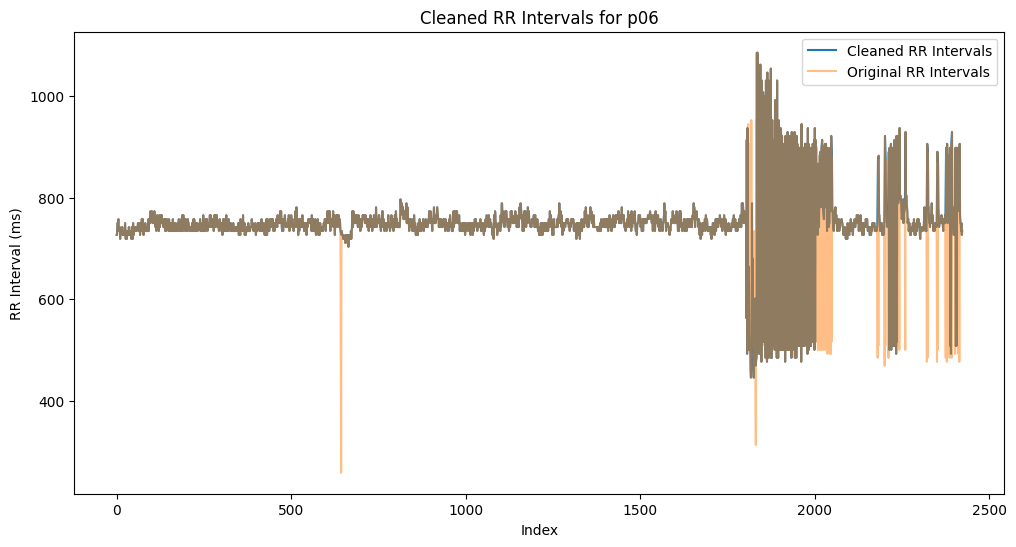

In [635]:
plt.figure(figsize=(12, 6))
plt.plot(rr_cleaned, label='Cleaned RR Intervals')
plt.plot(rr_data, label='Original RR Intervals', alpha=0.5)
plt.xlabel('Index')
plt.ylabel('RR Interval (ms)')
plt.title('Cleaned RR Intervals for p06')
plt.legend()
plt.show()

In [617]:
cleaned_windows = []
for start in range(0, len(rr_cleaned) - window_size + 1, stride):
    end = start + window_size
    window_rr = rr_cleaned[start:end]
    rmssd_value = RMSSD(window_rr)
    cleaned_windows.append(rmssd_value)

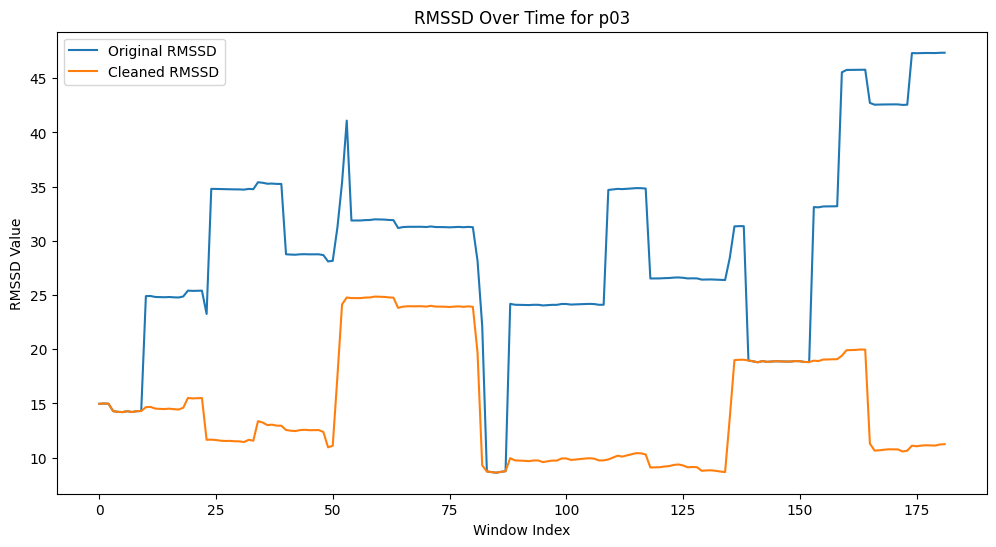

In [618]:
plt.figure(figsize=(12, 6))
plt.plot(windows, label='Original RMSSD')
plt.plot(cleaned_windows, label='Cleaned RMSSD')
plt.xlabel('Window Index')
plt.ylabel('RMSSD Value')
plt.title('RMSSD Over Time for p03')
plt.legend()
plt.show()

In [546]:
# -----------------------------
# HRV Metric
# -----------------------------
def RMSSD(rr_intervals):
    return np.sqrt(np.mean(np.diff(rr_intervals) ** 2))


# -----------------------------
# Local Variability Filter
# -----------------------------
def local_variability_filter(
    rr_intervals,
    threshold=0.25,
    window_size=5,
    remove_following=True
):

    rr = np.array(rr_intervals, dtype=float)
    rr_series = pd.Series(rr)

    local_median = rr_series.rolling(
        window=window_size,
        center=True,
        min_periods=1
    ).median().values

    deviation = np.abs(rr - local_median)
    outliers = deviation > (threshold * local_median)

    to_edit = outliers.copy()

    if remove_following:
        following_indices = np.where(outliers)[0] + 1
        following_indices = following_indices[following_indices < len(rr)]
        to_edit[following_indices] = True

    edited_indices = np.where(to_edit)[0]

    rr_corrected = rr.copy()
    rr_corrected[to_edit] = np.nan

    rr_corrected = pd.Series(rr_corrected).interpolate(
        method='linear',
        limit_direction='both'
    ).values

    n_edited = len(edited_indices)

    return rr_corrected, n_edited


# -----------------------------
# Sliding Window RMSSD
# -----------------------------
def compute_rmssd_windows(rr_data, window_size=300, stride=10):
    rmssd_values = []
    for start in range(0, len(rr_data) - window_size + 1, stride):
        end = start + window_size
        window_rr = rr_data[start:end]
        rmssd_values.append(RMSSD(window_rr))
    return rmssd_values


# -----------------------------
# Main Loop for p02–p50 (even)
# -----------------------------
report = []
good_records = []
for i in range(2, 51, 2):

    record_name = f"p{str(i).zfill(2)}"
    record_path = os.path.join(DATASET_PATH, record_name)

    try:
        # print(f"Processing {record_name}...")

        record = wfdb.rdrecord(record_path)
        qrs = wfdb.rdann(record_path, 'qrs')

        qrs_data = qrs.sample
        rr_data = np.diff(qrs_data) / record.fs * 1000  # ms

        # Original RMSSD windows
        raw_rmssd = compute_rmssd_windows(rr_data)

        # Filtering
        rr_cleaned, edited_count = local_variability_filter(
            rr_data,
            threshold=0.4,
            window_size=5,
            remove_following=False
        )
        print("Edited %:", edited_count / len(rr_data) * 100)
        cleaned_rmssd = compute_rmssd_windows(rr_cleaned)
        print(f"Raw RMSSD std: {np.std(raw_rmssd)}, Cleaned RMSSD std: {np.std(cleaned_rmssd)}")
        if edited_count / len(rr_data) < 0.01:  # If less than 5% of RR intervals were edited, consider it a good record
            good_records.append(record_name)
        report.append({
            "Record": record_name,
            "Total_RR": len(rr_data),
            "Edited_RR": edited_count,
            "Edited_%": (edited_count / len(rr_data)) * 100,
            "Mean_RMSSD_Raw": np.mean(raw_rmssd),
            "Mean_RMSSD_Cleaned": np.mean(cleaned_rmssd),
            "RMSSD_Difference": np.mean(cleaned_rmssd) - np.mean(raw_rmssd)
        })

    except Exception as e:
        print(f"Skipping {record_name} due to error: {e}")


# -----------------------------
# Final Report
# -----------------------------
report_df = pd.DataFrame(report)

print("\n========== SUMMARY REPORT ==========")
print(report_df)

print("\n========== OVERALL STATISTICS ==========")
print("Average % RR Edited:",
      report_df["Edited_%"].mean())

print("Average RMSSD Change:",
      report_df["RMSSD_Difference"].mean())

Edited %: 0.20635575732562939
Raw RMSSD std: 117.27126249172726, Cleaned RMSSD std: 116.14173923120867
Edited %: 0.395882818685669
Raw RMSSD std: 72.98825226644807, Cleaned RMSSD std: 6.255714757796265
Edited %: 0.35426731078904994
Raw RMSSD std: 16.52134549583482, Cleaned RMSSD std: 10.776756431774228
Edited %: 4.308943089430894
Raw RMSSD std: 67.29351585815478, Cleaned RMSSD std: 49.29347799427817
Edited %: 0.5865102639296188
Raw RMSSD std: 23.1431240477098, Cleaned RMSSD std: 14.760384258493454
Edited %: 5.603667855323485
Raw RMSSD std: 31.101042705607643, Cleaned RMSSD std: 12.465690454696327
Edited %: 0.9400705052878966
Raw RMSSD std: 47.87214686205745, Cleaned RMSSD std: 21.282090219006005
Edited %: 0.8588114050154586
Raw RMSSD std: 42.25368963926583, Cleaned RMSSD std: 19.2368013554724
Edited %: 0.9719222462203023
Raw RMSSD std: 73.69047927104147, Cleaned RMSSD std: 13.415330371981518
Edited %: 4.938271604938271
Raw RMSSD std: 71.94135745579004, Cleaned RMSSD std: 60.53573640620

In [547]:
good_records

['p02',
 'p04',
 'p06',
 'p10',
 'p14',
 'p16',
 'p18',
 'p24',
 'p26',
 'p28',
 'p32',
 'p36',
 'p38']

In [ ]:
rri_dataset_path = 'Utils/Dataset/AFDB/CSV_Files/rri_windows.csv'
rri_df = pd.read_csv(rri_dataset_path)
rri_df.head()

,Segment_Name,start_idx,end_idx,rri_0,rri_1,rri_2,rri_3,rri_4,rri_5,rri_6,...,rri_290,rri_291,rri_292,rri_293,rri_294,rri_295,rri_296,rri_297,rri_298,rri_299
0,04043_ep02,0,300,0.552,0.564,0.560,0.548,0.560,0.564,0.548,...,0.556,0.576,0.564,0.552,0.556,0.568,0.560,0.552,0.568,0.572
1,04043_ep02,10,310,0.556,0.556,0.568,0.544,0.552,0.556,0.560,...,0.556,0.552,0.564,0.568,0.552,0.552,0.568,0.560,0.556,0.556
2,04043_ep02,20,320,0.556,0.556,0.560,0.552,0.552,0.560,0.556,...,0.572,0.556,0.556,0.560,0.564,0.552,0.552,0.564,0.572,0.548
3,04043_ep02,30,330,0.548,0.556,0.572,0.556,0.548,0.560,0.564,...,0.548,0.564,0.568,0.556,0.560,0.580,0.556,0.552,0.560,0.564
4,04043_ep02,40,340,0.560,0.556,0.552,0.564,0.560,0.552,0.552,...,0.556,0.556,0.560,0.560,0.548,0.564,0.568,0.544,0.556,0.568


In [839]:
rri_columns = rri_df.columns[3:]  # Assuming first column is 'Segment_Name'

In [849]:
# Add a column with the sum of the first 10 RR interval columns
step_size = 10  # your sliding window step
rri_df['sum_first_10_rri'] = rri_df[rri_columns[:step_size]].sum(axis=1)

all_segments_results = []

for segment_name in rri_df['Segment_Name'].unique():
    segment_data = rri_df[rri_df['Segment_Name'] == segment_name].copy()

    # Precompute sum of first step_size RRIs per row
    segment_data['sum_first_step'] = segment_data[rri_columns[:step_size]].sum(axis=1)

    # Compute total RRI sum for this segment (avoiding double counting)
    sum_except_last = segment_data['sum_first_step'].iloc[:-1].sum()
    sum_last_row = segment_data[rri_columns].iloc[-1].sum()
    total_rri_sum = sum_except_last + sum_last_row

    # Compute cumulative sum including current row's full RRIs
    cumulative_with_current = []
    cumsum_so_far = 0
    for i, row in segment_data.iterrows():
        # Add sum of first step_size from previous rows + all RRIs in current row
        current_total = cumsum_so_far + row[rri_columns].sum()
        cumulative_with_current.append(current_total)
        # Update cumsum for next row
        cumsum_so_far += row['sum_first_step']

    # Compute time_to_af in hours
    segment_data['time_to_af'] = [
        round((total_rri_sum - x), 3) for x in cumulative_with_current
    ]

    all_segments_results.append(segment_data)

# Concatenate all segments
result_df = pd.concat(all_segments_results, ignore_index=False)
result_df.tail()


,Segment_Name,start_idx,end_idx,rri_0,rri_1,rri_2,rri_3,rri_4,rri_5,rri_6,...,rri_293,rri_294,rri_295,rri_296,rri_297,rri_298,rri_299,sum_first_10_rri,sum_first_step,time_to_af
16806,08434_ep01,7980,8280,0.900,0.880,0.892,0.892,0.868,0.884,0.860,...,0.772,0.424,0.500,0.412,1.012,0.804,0.812,8.768,8.768,27.844
16807,08434_ep01,7990,8290,0.852,0.844,0.844,0.844,0.832,0.828,0.836,...,0.536,0.488,0.560,0.548,0.500,0.536,0.392,8.452,8.452,22.836
16808,08434_ep01,8000,8300,0.860,0.452,0.996,0.876,0.448,0.560,0.552,...,0.836,0.844,0.476,0.956,0.852,0.456,0.956,7.472,7.472,14.716
16809,08434_ep01,8010,8310,0.856,0.836,0.820,0.832,0.820,0.860,0.844,...,0.828,0.452,0.508,0.980,0.844,0.460,0.916,8.428,8.428,7.476
16810,08434_ep01,8020,8320,0.832,0.844,0.840,0.852,0.832,0.832,0.844,...,0.464,0.896,0.456,0.948,0.804,0.460,0.908,8.412,8.412,-0.000


In [841]:
print(len(result_df))

16811


In [842]:
# remove the columns where time_to_af is negative and more than 3600
result_df = result_df[(result_df['time_to_af'] >= 0) & (result_df['time_to_af'] <= 3600)]
# result_df.head()
# Assign a label based on time_to_af if 3600 <= x < 3000 => 6, 3000 <= x < 2400 => 5, 2400 <= x < 1800 => 4, 1800 <= x < 1200 => 3, 1200 <= x < 600 => 2, 600 <= x < 300 => 1, x < 300 => 0
def assign_label(time_to_af):
    if time_to_af < 300:
        return 0
    elif time_to_af < 600:
        return 1
    elif time_to_af < 1200:
        return 2
    elif time_to_af < 1800:
        return 3
    elif time_to_af < 2400:
        return 4
    elif time_to_af < 3000:
        return 5
    else:
        return 6
result_df['label'] = result_df['time_to_af'].apply(assign_label)
result_df.head()

,Segment_Name,start_idx,end_idx,rri_0,rri_1,rri_2,rri_3,rri_4,rri_5,rri_6,...,rri_294,rri_295,rri_296,rri_297,rri_298,rri_299,sum_first_10_rri,sum_first_step,time_to_af,label
583,04043_ep02,5830,6130,0.588,0.604,0.616,0.604,0.596,0.592,0.612,...,0.588,0.584,0.600,0.616,0.600,0.588,5.984,5.984,3599.592,6
584,04043_ep02,5840,6140,0.608,0.616,0.592,0.592,0.584,0.604,0.600,...,0.580,0.608,0.608,0.588,0.580,0.596,5.984,5.984,3593.656,6
585,04043_ep02,5850,6150,0.620,0.600,0.588,0.588,0.612,0.600,0.592,...,0.608,0.596,0.596,0.604,0.616,0.596,5.996,5.996,3587.644,6
586,04043_ep02,5860,6160,0.596,0.588,0.596,0.612,0.600,0.584,0.600,...,0.596,0.588,0.608,0.600,0.584,0.596,5.972,5.972,3581.684,6
587,04043_ep02,5870,6170,0.604,0.620,0.596,0.588,0.592,0.616,0.604,...,0.608,0.604,0.592,0.588,0.600,0.612,6.016,6.016,3575.700,6


In [843]:
print(len(result_df))

9294


In [844]:
from scipy.signal import welch

def RMSSD(rr_intervals):
    return np.sqrt(np.mean(np.diff(rr_intervals) ** 2))

def pNN50(rr_intervals):
    rr_diff = np.diff(rr_intervals)
    nn50 = np.sum(np.abs(rr_diff) > 50)
    return (nn50 / len(rr_diff)) * 100

def SDNN(rr_intervals):
    return np.std(rr_intervals, ddof=1)  # standard deviation of RR intervals

def alpha1(rr_intervals):
    N = len(rr_intervals)
    # 1. Integrate the signal [cite: 61]
    y = np.cumsum(rr_intervals - np.mean(rr_intervals))
    
    # 2. Define scales for short-term (4 to 11 beats) 
    scales = np.arange(4, 12)
    fluctuations = []
    
    for n in scales:
        # Divide into segments of length n
        segments = N // n
        rms_n = []
        for i in range(segments):
            segment = y[i*n : (i+1)*n]
            x_axis = np.arange(n)
            # Fit a linear trend (detrending) [cite: 61]
            poly = np.polyfit(x_axis, segment, 1)
            trend = np.polyval(poly, x_axis)
            # Calculate RMS of the detrended segment
            rms_n.append(np.sqrt(np.mean((segment - trend)**2)))
        fluctuations.append(np.mean(rms_n))
    
    # 3. Calculate the slope of log(scale) vs log(fluctuation)
    alpha1 = np.polyfit(np.log(scales), np.log(fluctuations), 1)[0]
    return alpha1

def lfhf(rr_intervals,fs=250):
    """
    Calculates LF/HF Ratio using Welch's method.
    Significant decrease observed before onset of AF[cite: 206].
    """
    # Study uses LF (0.04-0.15 Hz) and HF (0.15-0.4 Hz) [cite: 58]
    freqs, psd = welch(rr_intervals, fs=fs, nperseg=len(rr_intervals))
    
    lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
    hf_mask = (freqs >= 0.15) & (freqs <= 0.4)
    
    lf_power = np.trapezoid(psd[lf_mask], freqs[lf_mask])
    hf_power = np.trapezoid(psd[hf_mask], freqs[hf_mask])
    
    return lf_power / hf_power if hf_power > 0 else 0.0

def _phi(data: np.ndarray, m: int=2, r: float = 0.2) -> np.ndarray:
    N = len(data)
    count = np.zeros(N - m + 1)
    for i in range(N - m + 1):
        template = data[i:i + m]
        for j in range(N - m + 1):
            if np.linalg.norm(template - data[j:j + m]) < r:
                count[i] += 1
    return count / (N - m + 1)

def approximate_entropy(data, m=2, r=0.2) -> float:
    phi_m = _phi(data, m, r)
    phi_m_plus_1 = _phi(data, m + 1, r)
    return np.log(np.sum(phi_m) / np.sum(phi_m_plus_1))

In [845]:
segment_names = result_df['Segment_Name'].unique()
# blacklist = ['04746_ep01', '04908_ep01']
blacklist = []
segment_names = [name for name in segment_names if name not in blacklist]
all_windows = []
segments_edited_more_than_1_percent = set()
for name in segment_names:
    segment = result_df[result_df['Segment_Name'] == name]
    segment_data = segment[rri_columns].values*1000
    for sample in segment_data:
        rr_cleaned, edited_count, edited_idx = local_variability_filter(
            sample,
            threshold=0.40,
            window_size=5,
            remove_following=False
        )
        edited_percent = edited_count / len(sample) * 100
        print(f"Segment: {name}, Edited % for sample: {edited_percent:.2f}%")
        if edited_percent > 5:
            segments_edited_more_than_1_percent.add(name)
        # Get the row index from the result_df for this segment and sample position
        sample_idx = segment.index[segment_data.tolist().index(sample.tolist())]
        
        result_df.loc[sample_idx, 'RMSSD'] = RMSSD(rr_cleaned)
        result_df.loc[sample_idx, 'pNN50'] = pNN50(rr_cleaned)
        result_df.loc[sample_idx, 'SDNN'] = SDNN(rr_cleaned)
        result_df.loc[sample_idx, 'alpha_1'] = alpha1(rr_cleaned)
        result_df.loc[sample_idx, 'LF/HF'] = lfhf(rr_cleaned)
        result_df.loc[sample_idx, 'ApEn'] = approximate_entropy(rr_cleaned)



Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample

In [846]:
print(segments_edited_more_than_1_percent)

{'08219_ep01', '05261_ep02', '04908_ep03', '04908_ep01', '04126_ep05', '07910_ep03', '04746_ep01', '08434_ep01', '04908_ep07', '05121_ep01'}


In [847]:
result_df.head()

,Segment_Name,start_idx,end_idx,rri_0,rri_1,rri_2,rri_3,rri_4,rri_5,rri_6,...,sum_first_10_rri,sum_first_step,time_to_af,label,RMSSD,pNN50,SDNN,alpha_1,LF/HF,ApEn
583,04043_ep02,5830,6130,0.588,0.604,0.616,0.604,0.596,0.592,0.612,...,5.984,5.984,3599.592,6,13.964120,0.0,10.745384,0.426420,0.0,0.979285
584,04043_ep02,5840,6140,0.608,0.616,0.592,0.592,0.584,0.604,0.600,...,5.984,5.984,3593.656,6,14.011939,0.0,10.803195,0.361772,0.0,0.991940
585,04043_ep02,5850,6150,0.620,0.600,0.588,0.588,0.612,0.600,0.592,...,5.996,5.996,3587.644,6,13.987094,0.0,10.766072,0.390479,0.0,0.997928
586,04043_ep02,5860,6160,0.596,0.588,0.596,0.612,0.600,0.584,0.600,...,5.972,5.972,3581.684,6,13.910368,0.0,10.690631,0.386458,0.0,1.009021
587,04043_ep02,5870,6170,0.604,0.620,0.596,0.588,0.592,0.616,0.604,...,6.016,6.016,3575.700,6,13.837084,0.0,10.677634,0.428852,0.0,1.002529


In [ ]:
save_df = result_df[['Segment_Name', 'time_to_af', 'label', 'RMSSD', 'pNN50', 'SDNN', 'alpha_1', 'LF/HF', 'ApEn']]
save_df.to_csv('Utils/Dataset/AFDB/CSV_Files/classification_dataset.csv', index=False)

In [663]:
segments = rri_df['Segment_Name'].unique()
print("Unique segments:", segments)

Unique segments: ['04043_ep02' '04048_ep03' '04126_ep05' '04746_ep01' '04908_ep01']


In [711]:
segment_01 = rri_df[rri_df['Segment_Name'] == '04048_ep03']
segment_01_data = segment_01[rri_columns].values*1000


In [712]:
rr_cleaned_list = []
for sample in segment_01_data:
    rr_cleaned, edited_count, edited_idx = local_variability_filter(
        sample,
        threshold=0.40,
        window_size=5,
    )
    rr_cleaned_list.append(rr_cleaned)
    print("Edited % for sample:", edited_count / len(sample) * 100)

Edited % for sample: 0.6666666666666667
Edited % for sample: 0.6666666666666667
Edited % for sample: 0.6666666666666667
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.0
Edited % for sample: 0.6666666666666667
Edited % for sample: 0.6666666666666667
Edited % for sample: 0.6666666666666667
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % for sample: 1.3333333333333335
Edited % f

In [713]:
windows_list = []
for rr_cleaned in rr_cleaned_list:
    rmssd = RMSSD(rr_cleaned)
    windows_list.append(rmssd)
raw_windows_list = []
for sample in segment_01_data:
    rmssd = RMSSD(sample)
    raw_windows_list.append(rmssd)

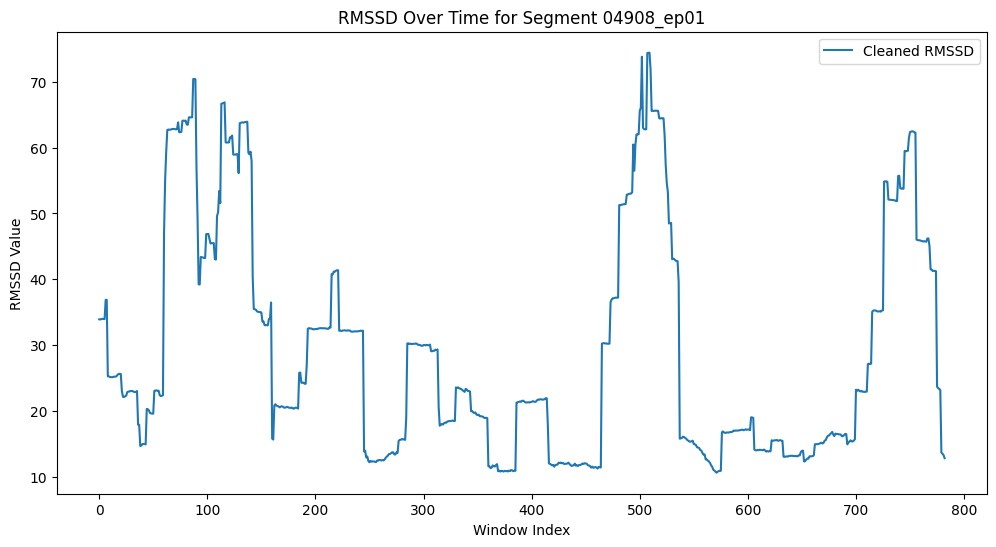

In [714]:
plt.figure(figsize=(12, 6))
plt.plot(windows_list, label='Cleaned RMSSD')
# plt.plot(raw_windows_list, alpha=0.5, label='Raw RMSSD')
plt.xlabel('Window Index')
plt.ylabel('RMSSD Value')
plt.title('RMSSD Over Time for Segment 04908_ep01')
plt.legend()
plt.show()

Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample: 0.00%
Segment: 04043_ep02, Edited % for sample

{'04746_ep01', '04908_ep01', '04126_ep05'}


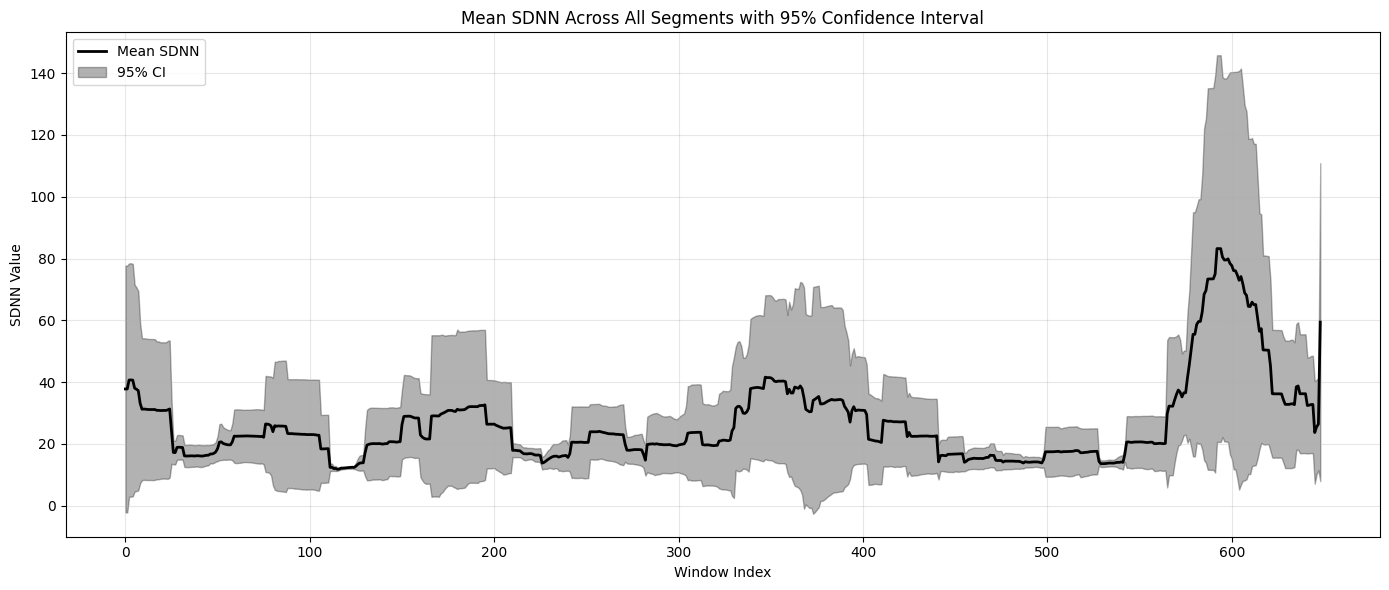

In [755]:
# Compute mean and 95% confidence interval across all segments
# Pad arrays to same length for easier computation
max_len = max(len(w) for w in all_windows)
min_len = min(len(w) for w in all_windows)
all_windows_padded = []
for w in all_windows:
    if len(w) > min_len:
        all_windows_padded.append(w[-min_len:]) # Keep only the last min_len values

# Compute statistics
mean_windows = np.nanmean(all_windows_padded, axis=0)
std_windows = np.nanstd(all_windows_padded, axis=0)
n_segments = np.sum(~np.isnan(all_windows_padded), axis=0)

ci_95 = 1.96 * (std_windows / np.sqrt(n_segments))

# Plot
plt.figure(figsize=(14, 6))
plt.plot(mean_windows, linewidth=2, label='Mean SDNN', color='black')
plt.fill_between(range(len(mean_windows)),
                 mean_windows - ci_95,
                 mean_windows + ci_95,
                 alpha=0.3, color='black', label='95% CI')

plt.xlabel('Window Index')
plt.ylabel('SDNN Value')
plt.title('Mean SDNN Across All Segments with 95% Confidence Interval')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
